# General notebook

In [1]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


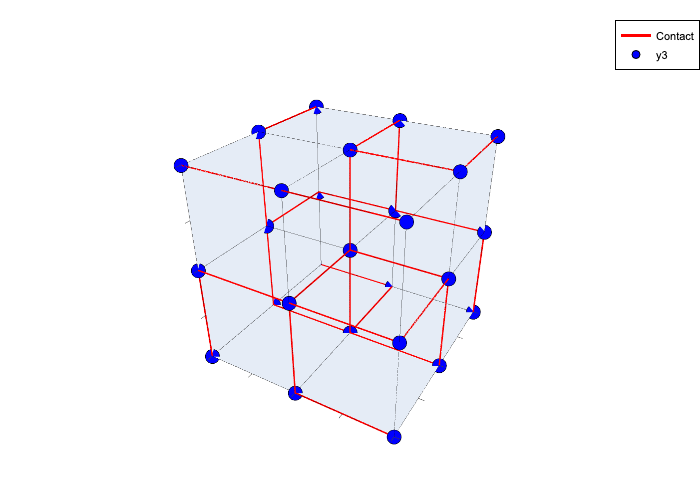

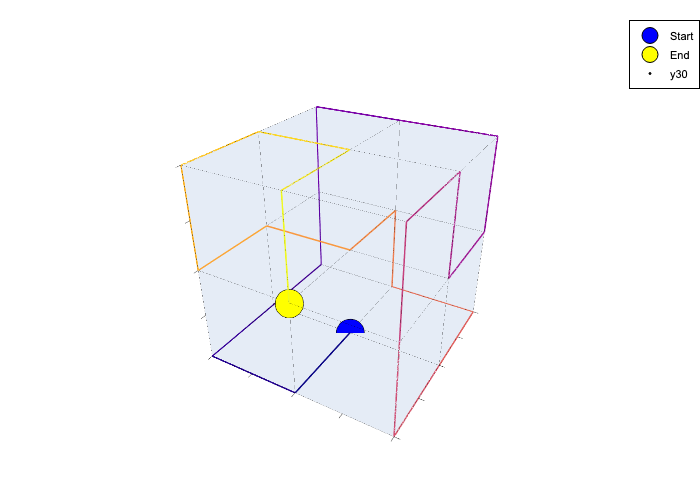

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:10


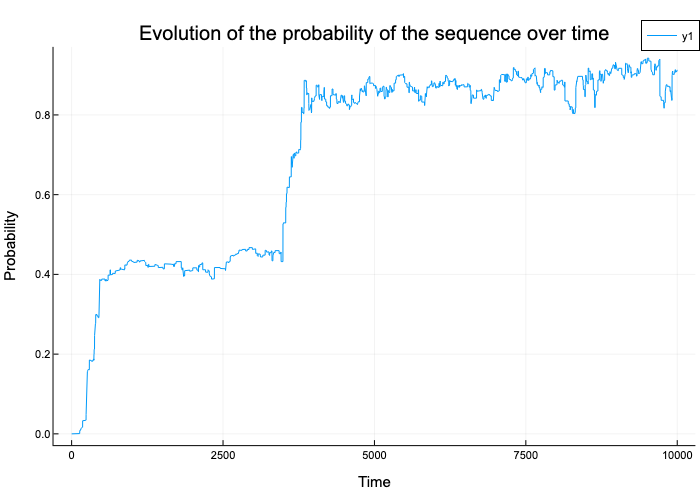

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


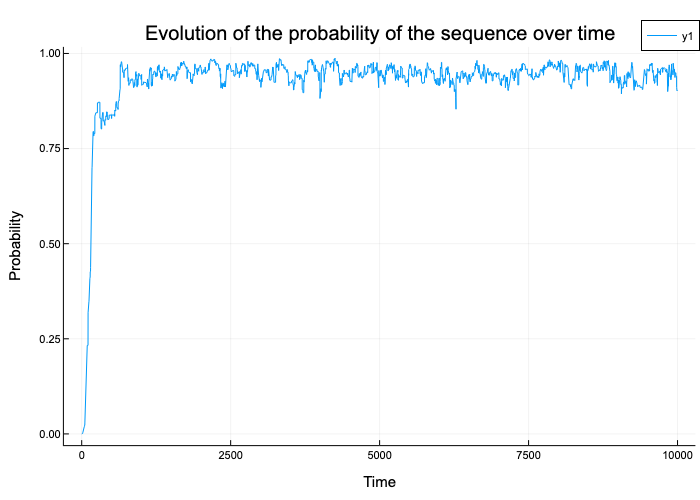

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:03


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


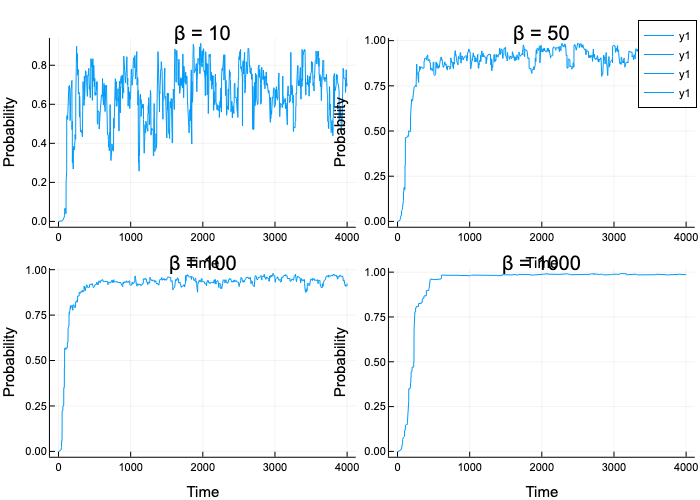

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([8, 4, 18, 18, 4, 15, 16, 3, 6, 19  …  6, 16, 19, 16, 15, 15, 9, 1…
  10.0   => ([7, 10, 20, 15, 10, 16, 19, 5, 2, 6  …  3, 4, 4, 4, 16, 2, 16, 8, …
  1000.0 => ([12, 18, 1, 5, 16, 16, 1, 19, 4, 4  …  2, 6, 18, 15, 16, 5, 16, 18…
  100.0  => ([3, 4, 15, 19, 7, 4, 16, 1, 19, 2  …  15, 5, 2, 7, 16, 2, 1, 18, 4…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:22


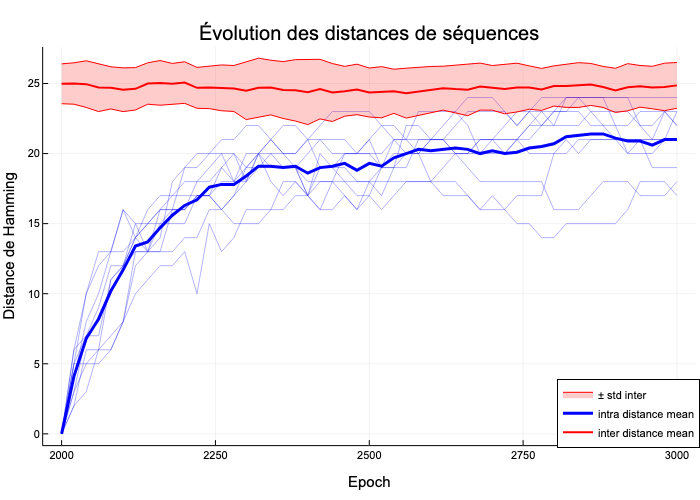

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.958002121281713
structure 1777 : 0.006454967518207722
structure 1233 : 0.003915135707242102
structure 2732 : 0.0037241922856421157
structure 532 : 0.003369788532009831
structure 493 : 0.0016733874618809009
structure 1271 : 0.0015917753923317057
structure 529 : 0.0015141435903820732
structure 1202 : 0.0011792162138721154
structure 1213 : 0.0011792162138721054
structure 1558 : 0.0011217051604834717
structure 999 : 0.0010149608012094784
structure 448 : 0.0009183745107741024
structure 3084 : 0.0009183745107741008
structure 1244 : 0.0009183745107740943
structure 557 : 0.0005855814418014403
structure 511 : 0.0005855814418014303
structure 1797 : 0.000557022297883085
structure 2332 : 0.0005298559998493888
structure 1243 : 0.0004794335348345782


In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:07


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 11
  16 => 33
  20 => 25
  12 => 20
  24 => 33
  8  => 28
  17 => 10
  1  => 36
  19 => 25
  22 => 25
  23 => 25
  6  => 38
  11 => 22
  9  => 16
  14 => 22
  3  => 32
  7  => 17
  25 => 21
  4  => 17
  ⋮  => ⋮

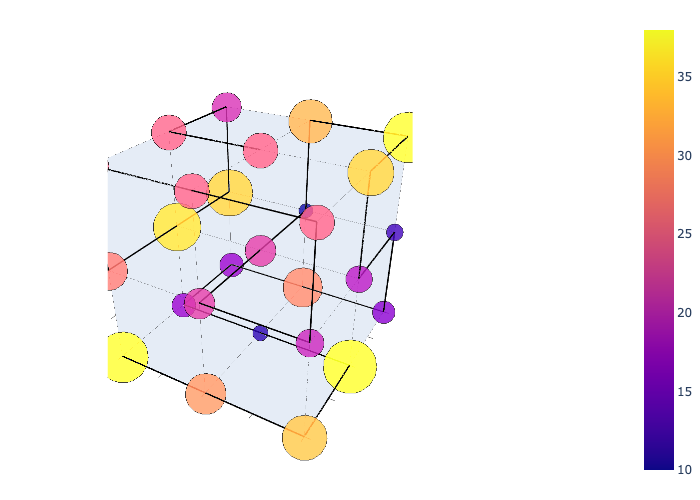

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[1234], n_mutations_per_position)

## Tree generation

In [11]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps, beta=100 )

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : CYS TRP LYS GLU CYS ASP LYS HIS PHE VAL ASN ASP ASP LYS ASP ARG VAL PHE ILE LEU TRP ARG LEU ARG TYR MET GLU
N4 : CYS MET GLY GLU PRO ASP LYS VAL MET ILE ASP THR TYR LYS GLU LYS CYS TRP ILE CYS VAL LYS CYS ARG GLU VAL ASN
N5 : THR MET LYS GLU CYS LYS LYS ALA MET CYS ARG ASP GLU ARG ASP ARG LEU LEU CYS ALA CYS LYS ALA ASP TYR VAL SER
N7 : ASN PHE LYS GLU ALA SER LYS ILE PHE CYS ARG ASP GLN ARG ASP ARG LEU PHE CYS VAL CYS ARG CYS ASN TYR VAL ASN
N1 : THR TRP LYS GLU MET LYS LYS VAL LEU VAL ASP ASP ASP LYS ASP ARG PHE LEU LYS VAL LEU ARG ILE LYS GLU ILE SER
N6 : THR MET ASP ASP MET HIS LYS MET MET CYS LYS ASP PHE SER ASP LYS LEU MET CYS ILE ALA PRO LEU ASP TYR PHE SER
N2 : LYS HIS LYS GLU CYS HIS LYS ILE PHE LEU ASP ASP THR LYS ASP ARG LEU PHE ILE LEU VAL ARG MET LYS GLU ALA ASN


In [12]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     20    19    17    16    22    14    
N4    20    0     21    22    21    23    19    
N5    19    21    0     13    17    15    19    
N7    17    22    13    0     19    20    15    
N1    16    21    17    19    0     21    16    
N6    22    23    15    20    21    0     22    
N2    14    19    19    15    16    22    0     


In [13]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [14]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [15]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : THR MET LYS GLU PRO ASP LYS ILE MET ILE ASP ASP GLN ARG ASP ARG LEU PHE ILE LEU VAL ARG LEU ASP TYR VAL ASN
N2 : CYS MET LYS GLU PRO ASP LYS VAL MET ILE ASP ASP ASP LYS ASP ARG VAL PHE ILE LEU VAL ARG LEU ARG TYR VAL ASN
N3 : CYS TRP LYS GLU CYS ASP LYS HIS PHE VAL ASN ASP ASP LYS ASP ARG VAL PHE ILE LEU TRP ARG LEU ARG TYR MET GLU
N4 : CYS MET GLY GLU PRO ASP LYS VAL MET ILE ASP THR TYR LYS GLU LYS CYS TRP ILE CYS VAL LYS CYS ARG GLU VAL ASN
N5 : THR MET LYS GLU MET SER LYS ILE MET CYS ARG ASP GLN ARG ASP ARG LEU PHE CYS ILE ALA ARG LEU ASP TYR VAL ASN
N6 : THR MET ASP ASP MET HIS LYS MET MET CYS LYS ASP PHE SER ASP LYS LEU MET CYS ILE ALA PRO LEU ASP TYR PHE SER
N7 : ASN PHE LYS GLU ALA SER LYS ILE PHE CYS ARG ASP GLN ARG ASP ARG LEU PHE CYS VAL CYS ARG CYS ASN TYR VAL ASN


In [16]:
@which root(tree)

root(t::Tree)
     @ TreeTools ~/.julia/packages/TreeTools/nIWnY/src/objects.jl:194

In [17]:
typeof(root)

typeof(root) (singleton type of function root, subtype of Function)

In [21]:
reconstruction_error_hamming(result, seq_dict)

5.857142857142857

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


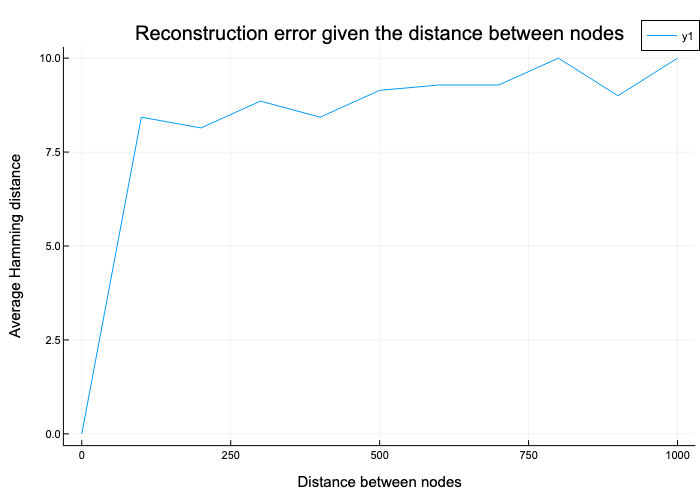

In [24]:
distance_btw_nodes = 0:100:1000
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)